In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Metrics Score 2018-2025.csv')
df

,File Name,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number Of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,/Users/summer-2024/Desktop/code metrics 25/All...,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,/Users/summer-2024/Desktop/code metrics 25/All...,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,/Users/summer-2024/Desktop/code metrics 25/All...,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,/Users/summer-2024/Desktop/code metrics 25/All...,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,/Users/summer-2024/Desktop/code metrics 25/All...,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,/Users/summer-2024/Desktop/code metrics 25/All...,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1576,/Users/summer-2024/Desktop/code metrics 25/All...,1128,28.635,9.840426,29.787234,25,91,45.120000,-1,3,NaN,6,IST341,sp2025,2025
1577,/Users/summer-2024/Desktop/code metrics 25/All...,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,/Users/summer-2024/Desktop/code metrics 25/All...,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [77]:
df_tidy = df.dropna()  # NaN values are execution times that timed out by 10 sec
df_tidy = df_tidy.drop('File Name', axis=1)
df_tidy = df_tidy.rename(columns={'Number Of Functions': 'Number of Functions'})
df_tidy

,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,800,24.750,4.125000,37.250000,7,11,114.285714,3,1,1.288,7,CS35,sp2025,2025
1575,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1577,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [78]:
all_metrics = [
    'LOC', 
    'Comment Percentage', 
    'Docstring Percentage', 
    'Empty Percentage', 
    'Number of Functions', 
    'Number of Loops', 
    'CycloComplexity', 
    'Average Function Length', 
    'Max Depth', 
    'Execution Time', 
    'Weeks Covered'
]

color_palette = ['#CC6677', '#DDCC77', '#117733', '#88CCEE']

#### Metric Graphs by Year and Class

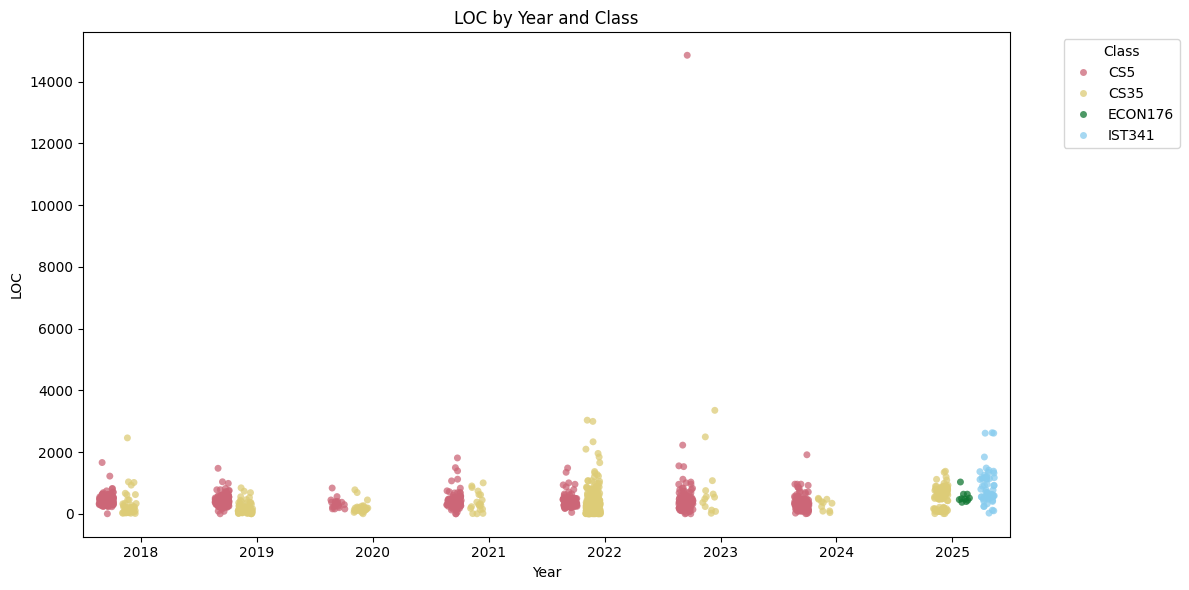

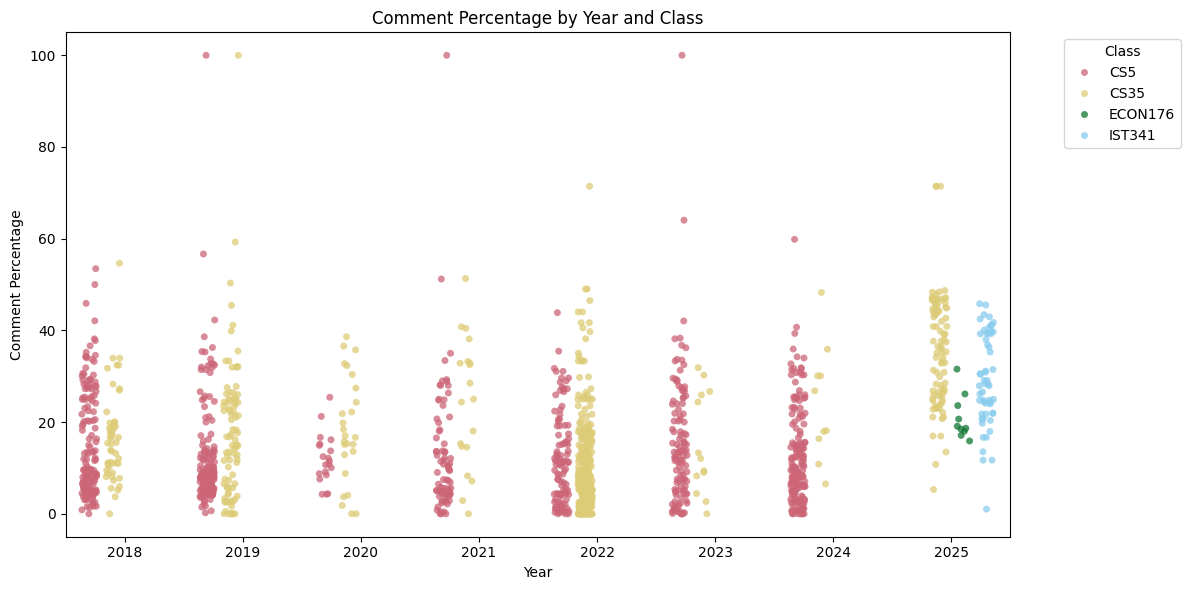

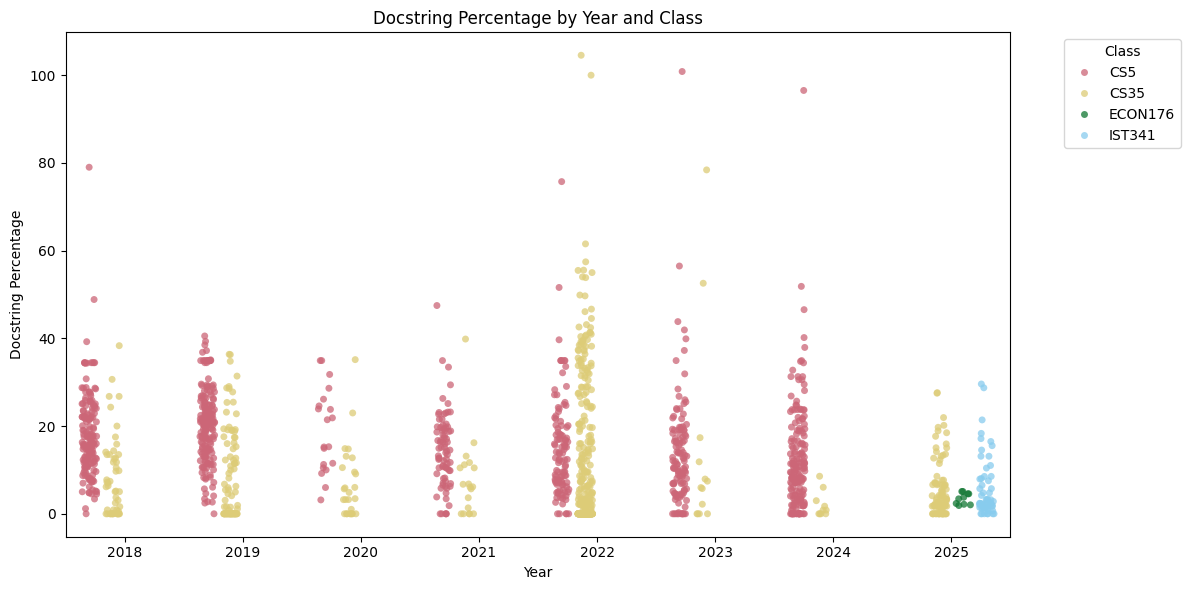

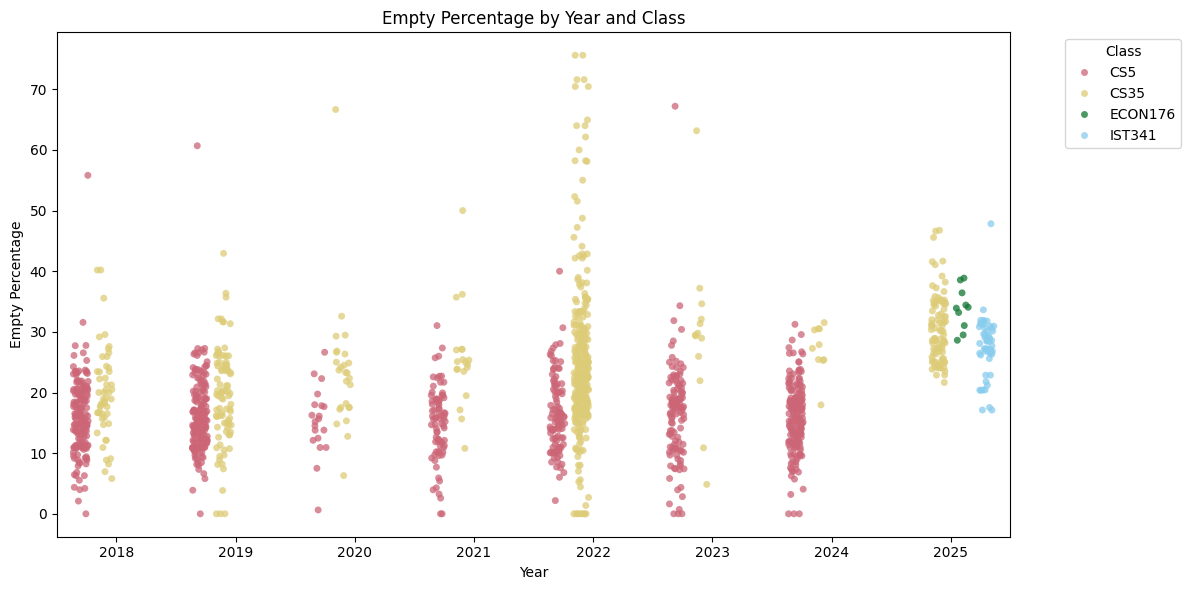

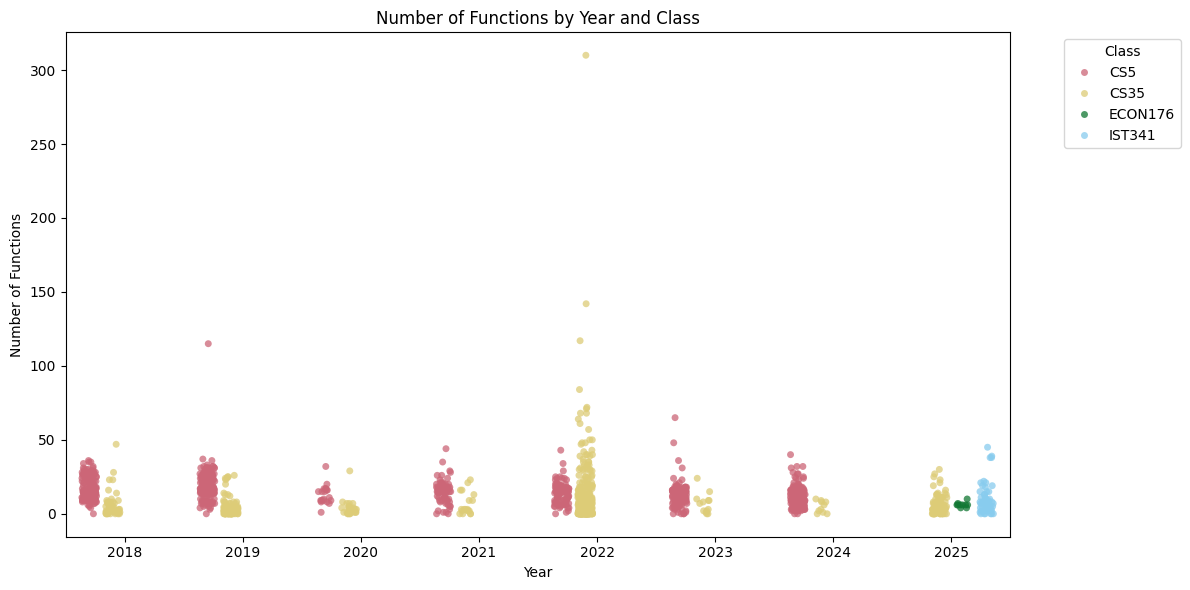

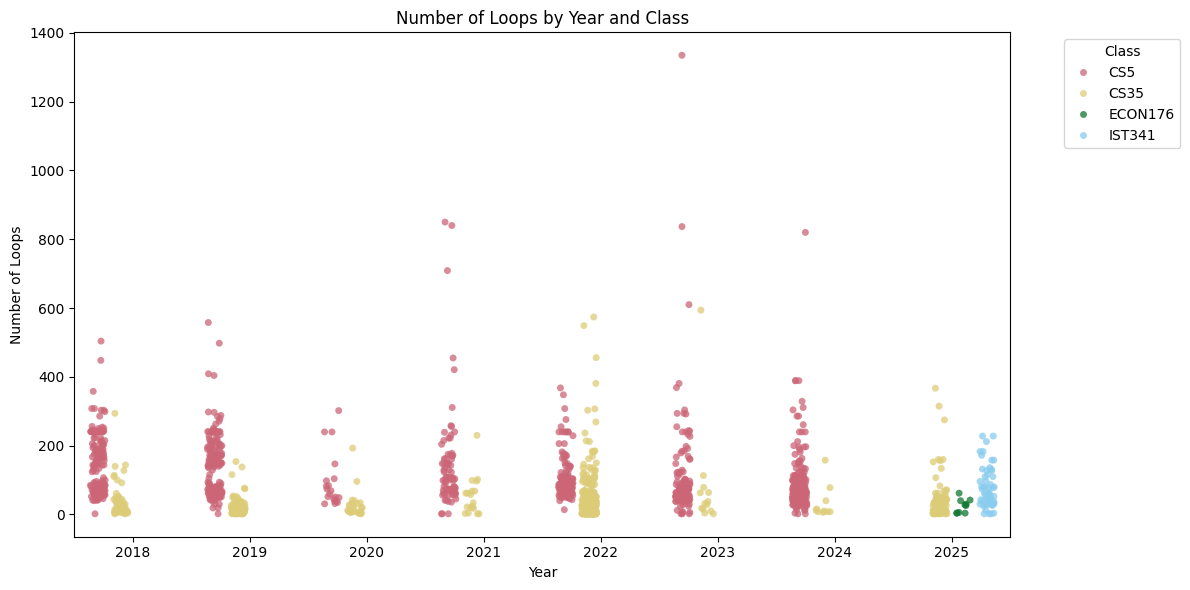

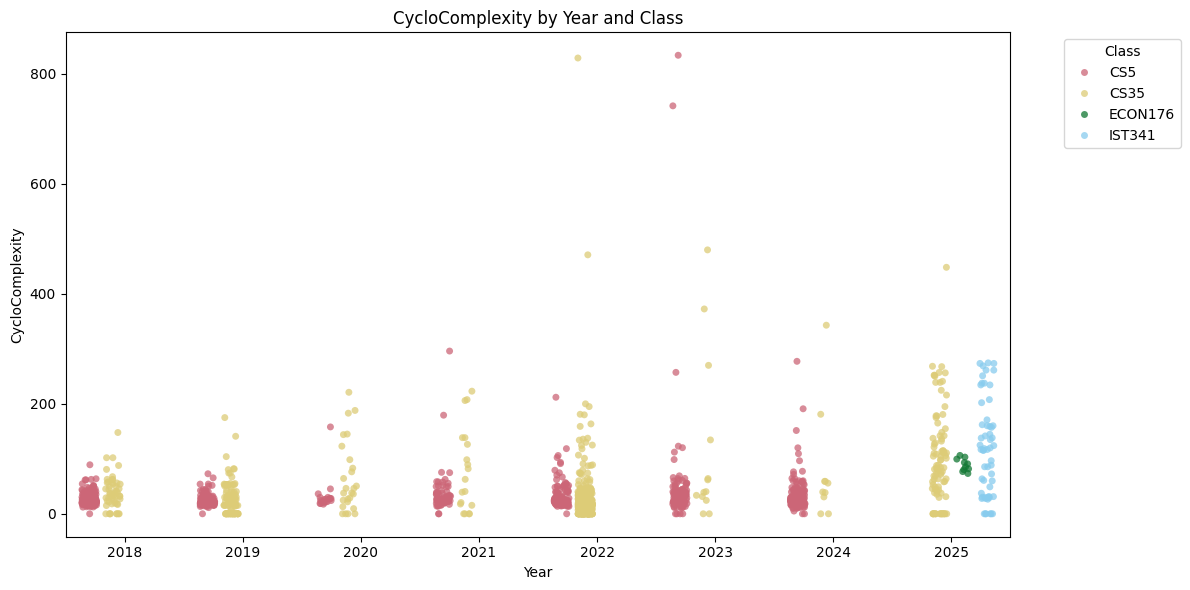

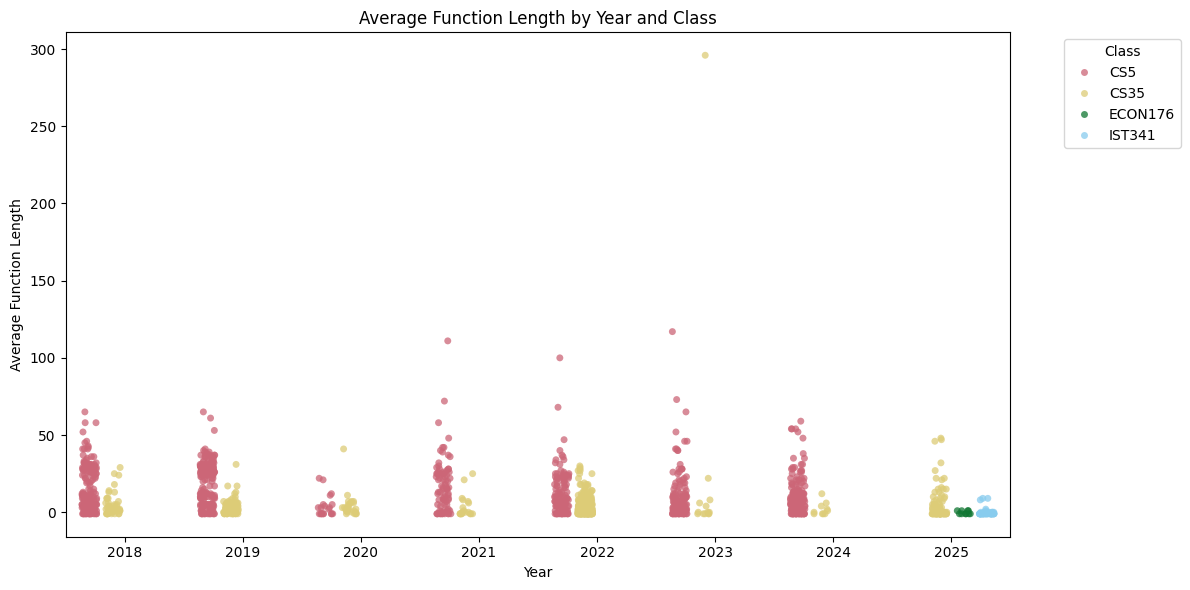

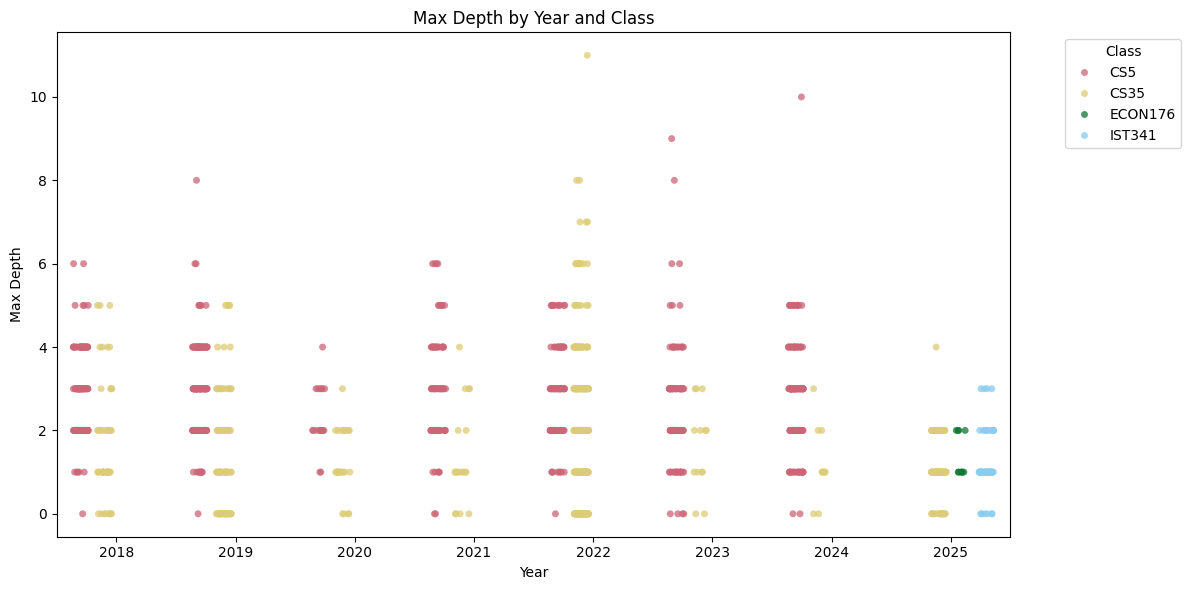

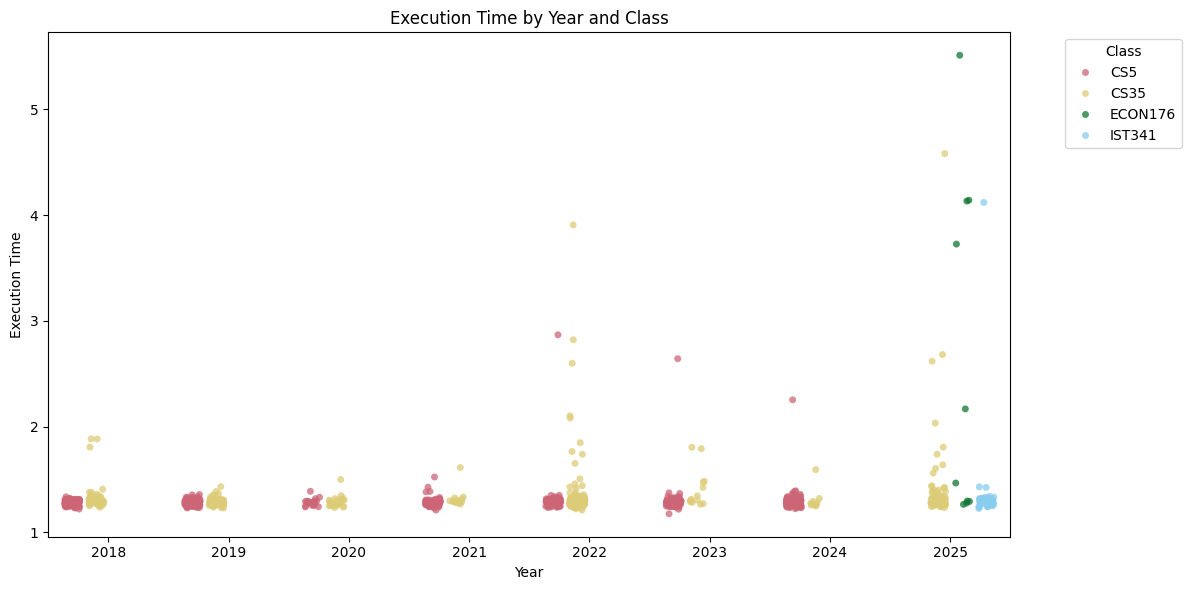

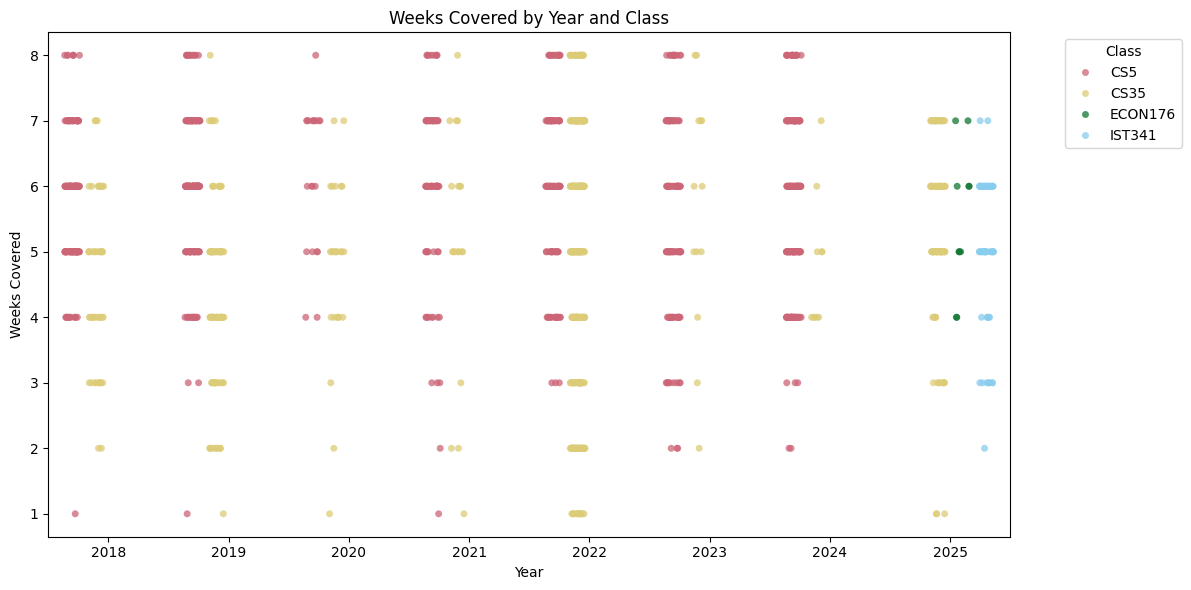

In [79]:
for metric in all_metrics:
    plt.figure(figsize=(12, 6))
    sns.stripplot(
        data = df_tidy,
        x = 'Year',
        y = metric,
        hue = 'Class',
        palette = color_palette,
        dodge = True,  # separate data points by hue on x axis
        jitter = 0.25,  # spread out data points on x axis
        alpha = 0.75  # transparency of data points
    )
    plt.title(f'{metric} by Year and Class')
    plt.ylabel(metric)
    plt.xlabel('Year')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#### Average Metrics by Year

In [80]:
num_files = df.groupby('Year').size().reset_index(name='Number of Files')

year_avg = df_tidy.groupby('Year')[all_metrics].mean().reset_index()

year_avg = pd.merge(year_avg, num_files, on='Year')
year_avg

,Year,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,2018,401.117371,15.321249,15.661373,16.985123,15.000000,115.737089,30.444293,12.812207,2.525822,1.292239,5.492958,213
1,2019,337.069343,13.484420,16.665165,17.135236,14.974453,105.762774,24.796894,13.981752,2.474453,1.284124,5.397810,274
2,2020,259.282609,15.612587,12.141690,19.879265,7.891304,55.913043,51.135961,4.152174,1.717391,1.286478,5.369565,47
3,2021,440.765306,14.982980,13.303743,16.960795,13.489796,130.255102,43.698966,15.346939,2.724490,1.289041,5.775510,101
4,2022,324.510588,10.492466,12.625567,22.701320,12.585882,60.517647,31.258784,5.585882,2.152941,1.310388,5.098824,426
5,2023,581.210526,15.134519,13.916577,17.849392,12.248120,111.962406,55.144701,13.030075,2.473684,1.305218,5.518797,135
6,2024,326.063830,12.977053,11.724064,16.553816,11.462766,89.734043,35.060444,9.739362,2.632979,1.290441,5.643617,195
7,2025,680.622642,32.568874,5.601139,29.643284,7.522013,56.106918,107.021332,2.616352,1.163522,1.455560,5.308176,189


In [91]:
relative = year_avg.copy()
for column in all_metrics:
    min = year_avg[column].min()
    max = year_avg[column].max()
    relative[column] = (year_avg[column] - min) / (max - min)
    
relative

,Year,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,2018,0.336628,0.218730,0.909274,0.032951,1.000000,0.804713,0.068683,0.800894,0.872728,0.047338,0.582447,213
1,2019,0.184617,0.135527,1.000000,0.044419,0.996584,0.670545,0.000000,0.892763,0.839819,0.000000,0.441839,274
2,2020,0.000000,0.231927,0.591155,0.254055,0.049384,0.000000,0.320331,0.120640,0.354824,0.013732,0.400099,47
3,2021,0.430727,0.203408,0.696185,0.031092,0.798047,1.000000,0.229884,1.000000,1.000000,0.028680,1.000000,101
4,2022,0.154811,0.000000,0.634889,0.469653,0.677170,0.061938,0.078588,0.233259,0.633850,0.153201,0.000000,426
5,2023,0.764057,0.210272,0.751574,0.098978,0.632003,0.753939,0.369085,0.818008,0.839327,0.123043,0.620632,135
6,2024,0.158497,0.112545,0.553408,0.000000,0.526980,0.454938,0.124824,0.559519,0.941375,0.036850,0.805090,195
7,2025,1.000000,1.000000,0.000000,1.000000,0.000000,0.002608,1.000000,0.000000,0.000000,1.000000,0.309379,189


In [92]:
melted = relative.melt(
    id_vars = ['Year'],
    value_vars = all_metrics,
    var_name = 'Metric',
    value_name = 'Relative Value'
)

melted

,Year,Metric,Relative Value
0,2018,LOC,0.336628
1,2019,LOC,0.184617
2,2020,LOC,0.000000
3,2021,LOC,0.430727
4,2022,LOC,0.154811
...,...,...,...
83,2021,Weeks Covered,1.000000
84,2022,Weeks Covered,0.000000
85,2023,Weeks Covered,0.620632
86,2024,Weeks Covered,0.805090


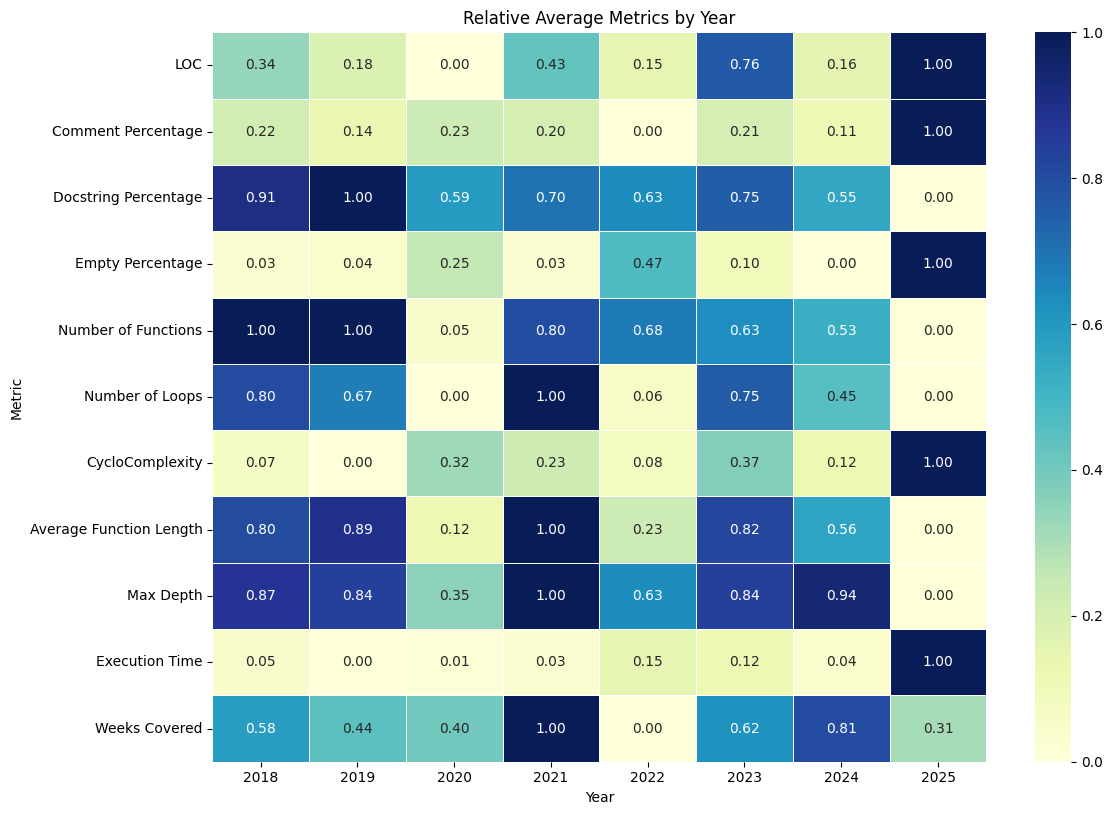

In [93]:
heatmap_data = melted.pivot_table(
    index = 'Metric',
    columns = 'Year',
    values = 'Relative Value',
)

heatmap_data = heatmap_data.reindex(all_metrics)

plt.figure(figsize=(12, len(all_metrics) * 0.75))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Relative Average Metrics by Year')
plt.xlabel('Year')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

#### Average Metrics by Class

In [81]:
num_files = df.groupby('Class').size().reset_index(name='Number of Files')

class_avg = df_tidy.groupby('Class')[all_metrics].mean().reset_index()

class_avg = pd.merge(class_avg, num_files, on='Class')
class_avg

,Class,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,CS35,326.334951,16.656393,9.746603,24.574467,8.838188,40.190939,46.967793,3.909385,1.655340,1.324662,4.825243,637
1,CS5,423.094007,13.005955,16.076838,16.030041,15.545241,124.318449,32.225721,14.345476,2.796710,1.287465,5.803760,865
2,ECON176,546.000000,20.915000,3.493027,33.857237,6.100000,24.600000,89.037381,-0.200000,1.400000,2.627400,5.500000,11
3,IST341,885.368421,29.195175,5.897687,27.539673,9.824561,78.789474,119.301079,-0.228070,1.210526,1.343842,5.122807,67


In [94]:
relative = class_avg.copy()
for column in all_metrics:
    min = class_avg[column].min()
    max = class_avg[column].max()
    relative[column] = (class_avg[column] - min) / (max - min)
    
relative

,Class,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,CS35,0.000000,0.225486,0.496954,0.479292,0.289901,0.156350,0.169302,0.283902,0.280430,0.027760,0.000000,637
1,CS5,0.173083,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,865
2,ECON176,0.392937,0.488538,0.000000,1.000000,0.000000,0.000000,0.652442,0.001926,0.119453,1.000000,0.689571,11
3,IST341,1.000000,1.000000,0.191092,0.645622,0.394332,0.543425,1.000000,0.000000,0.000000,0.042074,0.304097,67


In [95]:
melted = relative.melt(
    id_vars = ['Class'],
    value_vars = all_metrics,
    var_name = 'Metric',
    value_name = 'Relative Value'
)

melted

,Class,Metric,Relative Value
0,CS35,LOC,0.000000
1,CS5,LOC,0.173083
2,ECON176,LOC,0.392937
3,IST341,LOC,1.000000
4,CS35,Comment Percentage,0.225486
5,CS5,Comment Percentage,0.000000
6,ECON176,Comment Percentage,0.488538
7,IST341,Comment Percentage,1.000000
8,CS35,Docstring Percentage,0.496954
9,CS5,Docstring Percentage,1.000000


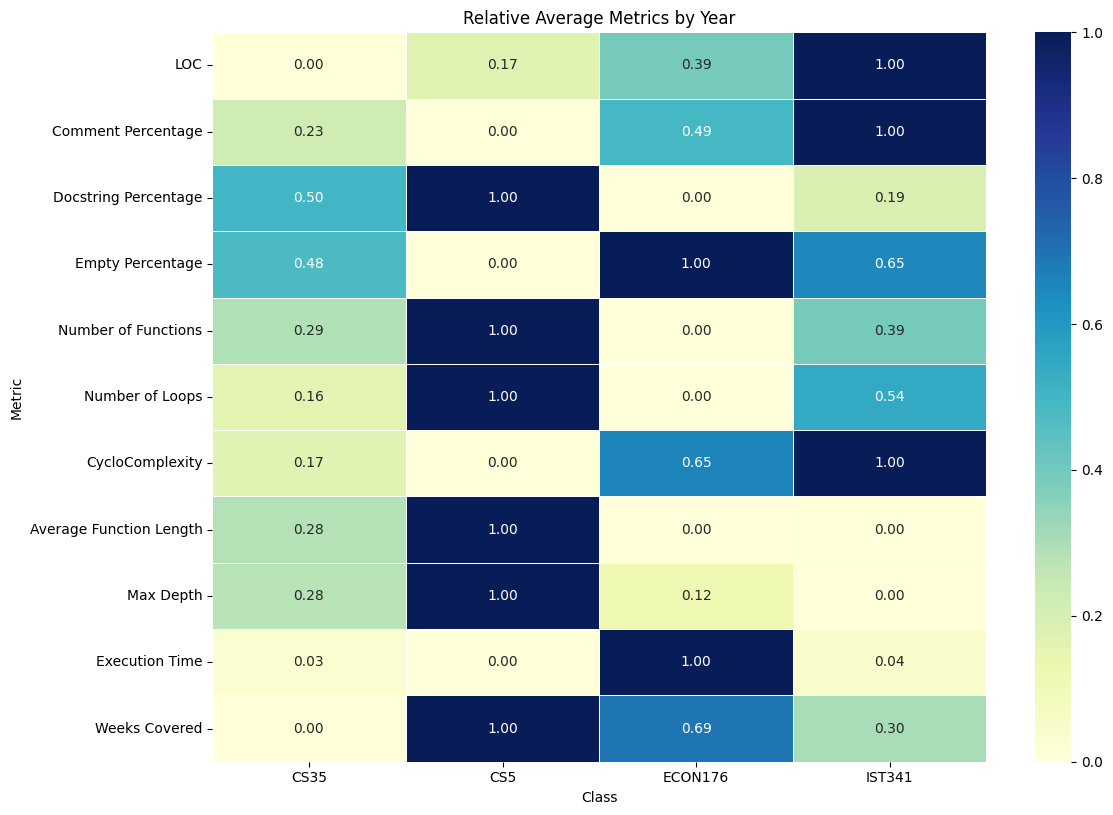

In [96]:
heatmap_data = melted.pivot_table(
    index = 'Metric',
    columns = 'Class',
    values = 'Relative Value',
)

heatmap_data = heatmap_data.reindex(all_metrics)

plt.figure(figsize=(12, len(all_metrics) * 0.75))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Relative Average Metrics by Year')
plt.xlabel('Class')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

#### Average Metrics by Year and Class

In [82]:
num_files = df.groupby(['Year', 'Class']).size().reset_index(name='Number of Files')

yearclass_avg = df_tidy.groupby(['Year', 'Class'])[all_metrics].mean().reset_index()

yearclass_avg = pd.merge(yearclass_avg, num_files, on=['Year', 'Class'])
yearclass_avg

,Year,Class,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,2018,CS35,270.980392,16.718373,8.221612,19.823467,5.882353,39.176471,39.395895,4.568627,1.705882,1.332314,4.627451,51
1,2018,CS5,442.086420,14.881414,18.003519,16.091570,17.870370,139.839506,27.626195,15.407407,2.783951,1.279623,5.765432,162
2,2019,CS35,168.101124,17.684281,8.846446,19.453669,4.505618,21.910112,28.680073,3.123596,1.460674,1.286539,4.292135,89
3,2019,CS5,418.356757,11.463946,20.426603,16.019882,20.010811,146.102703,22.928770,19.205405,2.962162,1.282962,5.929730,185
4,2020,CS35,200.692308,18.471885,6.902063,23.433853,3.923077,26.846154,65.568506,4.192308,1.269231,1.287346,4.769231,26
5,2020,CS5,335.450000,11.895500,18.953205,15.258301,13.050000,93.700000,32.373652,4.100000,2.300000,1.285350,6.150000,21
6,2021,CS35,392.842105,24.255579,7.867175,25.631241,6.684211,52.473684,79.265891,3.789474,1.368421,1.311211,5.052632,19
7,2021,CS5,452.291139,12.752861,14.611272,14.875498,15.126582,148.962025,35.144896,18.126582,3.050633,1.283709,5.949367,82
8,2022,CS35,296.264151,10.005481,11.817199,24.816701,12.012579,42.783019,30.092946,2.959119,1.924528,1.313984,4.798742,318
9,2022,CS5,408.457944,11.939766,15.028009,16.414487,14.289720,113.224299,34.723611,13.392523,2.831776,1.299701,5.990654,108


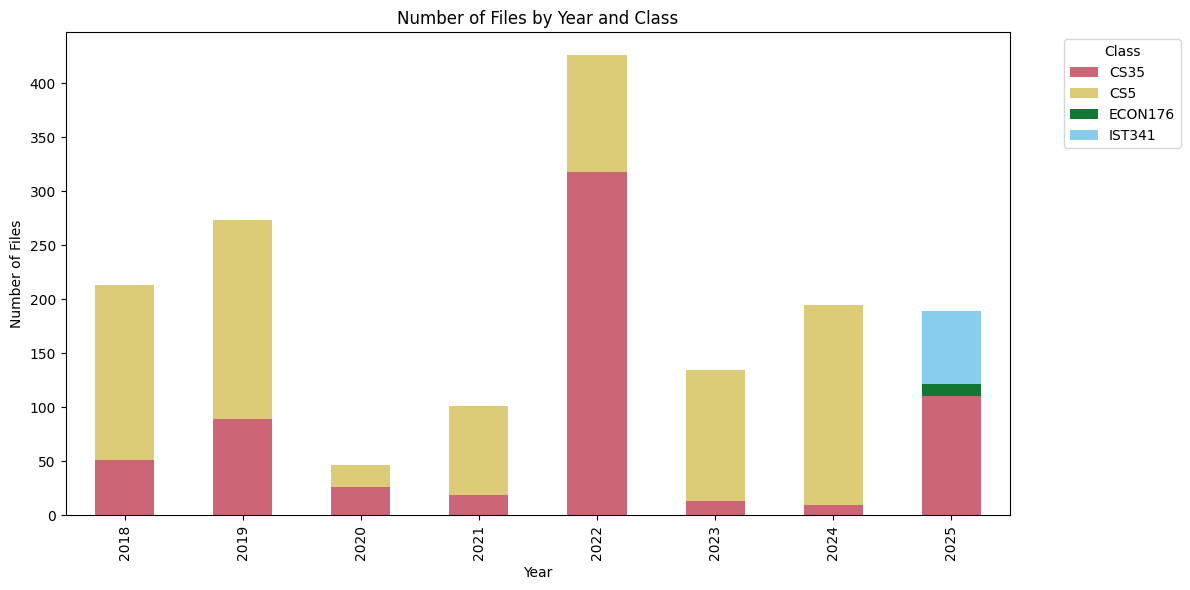

In [83]:
metric = 'Number of Files'

pivot_df = yearclass_avg.pivot(index='Year', columns='Class', values='Number of Files')

pivot_df.plot(
    kind = 'bar',
    stacked = True,
    figsize = (12, 6),
    color = color_palette
)

plt.title(f'{metric} by Year and Class')
plt.ylabel(metric)
plt.xlabel('Year')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Relative Average Metrics Graphs by Year and Class

x axis: Metrics
- 1: Metrics as subgroups on the x axis, with years listed in chronological order from left to right in each subgroup.
- 2: Years as subgroups on the x axis, with metrics listed in each subgroup.

y axis: Relative Value
- Relative values of the data points are taken based on overall metric values, since different metrics yielded values in very different ranges.
- For each metric, the minimum value is set to 0 and the maximum value is set to 1. All other values are curved between 0-1.

In [98]:
relative = yearclass_avg.copy()
for column in all_metrics:
    min = yearclass_avg[column].min()
    max = yearclass_avg[column].max()
    relative[column] = (yearclass_avg[column] - min) / (max - min)
    
relative

,Year,Class,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Number of Files
0,2018,CS35,0.143432,0.258982,0.333944,0.260670,0.121787,0.135900,0.170792,0.186717,0.307521,0.039094,0.180485,51
1,2018,CS5,0.381985,0.188112,0.867766,0.064065,0.866952,0.928198,0.048720,0.608630,0.862672,0.000000,0.793005,162
2,2019,CS35,0.000000,0.296246,0.368042,0.241188,0.036210,0.000000,0.059651,0.130468,0.181251,0.005131,0.000000,89
3,2019,CS5,0.348901,0.056267,1.000000,0.060289,1.000000,0.977495,0.000000,0.756472,0.954442,0.002477,0.881439,185
4,2020,CS35,0.045438,0.326632,0.261932,0.450873,0.000000,0.038851,0.442245,0.172069,0.082668,0.005730,0.256798,26
5,2020,CS5,0.233315,0.072916,0.919593,0.020167,0.567322,0.565044,0.097959,0.168476,0.613462,0.004249,1.000000,21
6,2021,CS35,0.313329,0.549765,0.314601,0.566636,0.171630,0.240560,0.584310,0.156388,0.133746,0.023436,0.409339,19
7,2021,CS5,0.396212,0.105993,0.682643,0.000000,0.696400,1.000000,0.126702,0.714478,1.000000,0.003031,0.892009,82
8,2022,CS35,0.178682,0.000000,0.530164,0.523725,0.502837,0.164286,0.074304,0.124065,0.420113,0.025494,0.272682,318
9,2022,CS5,0.335101,0.074624,0.705385,0.081077,0.644382,0.718716,0.122332,0.530199,0.887300,0.014897,0.914232,108


In [99]:
melted = relative.melt(
    id_vars = ['Year', 'Class'],
    value_vars = all_metrics,
    var_name = 'Metric',
    value_name = 'Relative Value'
)

melted

,Year,Class,Metric,Relative Value
0,2018,CS35,LOC,0.143432
1,2018,CS5,LOC,0.381985
2,2019,CS35,LOC,0.000000
3,2019,CS5,LOC,0.348901
4,2020,CS35,LOC,0.045438
...,...,...,...,...
182,2024,CS35,Weeks Covered,0.273360
183,2024,CS5,Weeks Covered,0.752948
184,2025,CS35,Weeks Covered,0.597481
185,2025,ECON176,Weeks Covered,0.650136


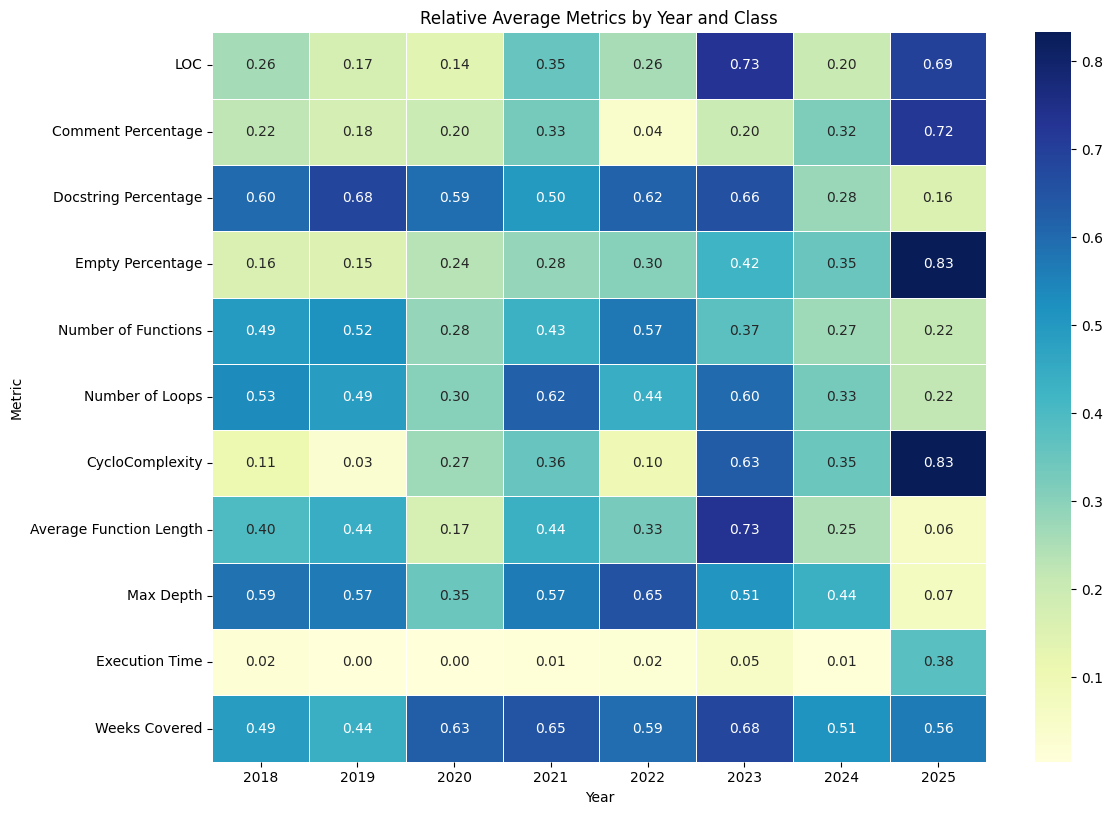

In [100]:
heatmap_data = melted.pivot_table(
    index = 'Metric',
    columns = 'Year',
    values = 'Relative Value',
)

heatmap_data = heatmap_data.reindex(all_metrics)

plt.figure(figsize=(12, len(all_metrics) * 0.75))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Relative Average Metrics by Year and Class')
plt.xlabel('Year')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

/var/folders/wq/lbzxr1pd36g5zc91_cmkdntw0000gq/T/ipykernel_38628/123542746.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_labels, rotation=90)


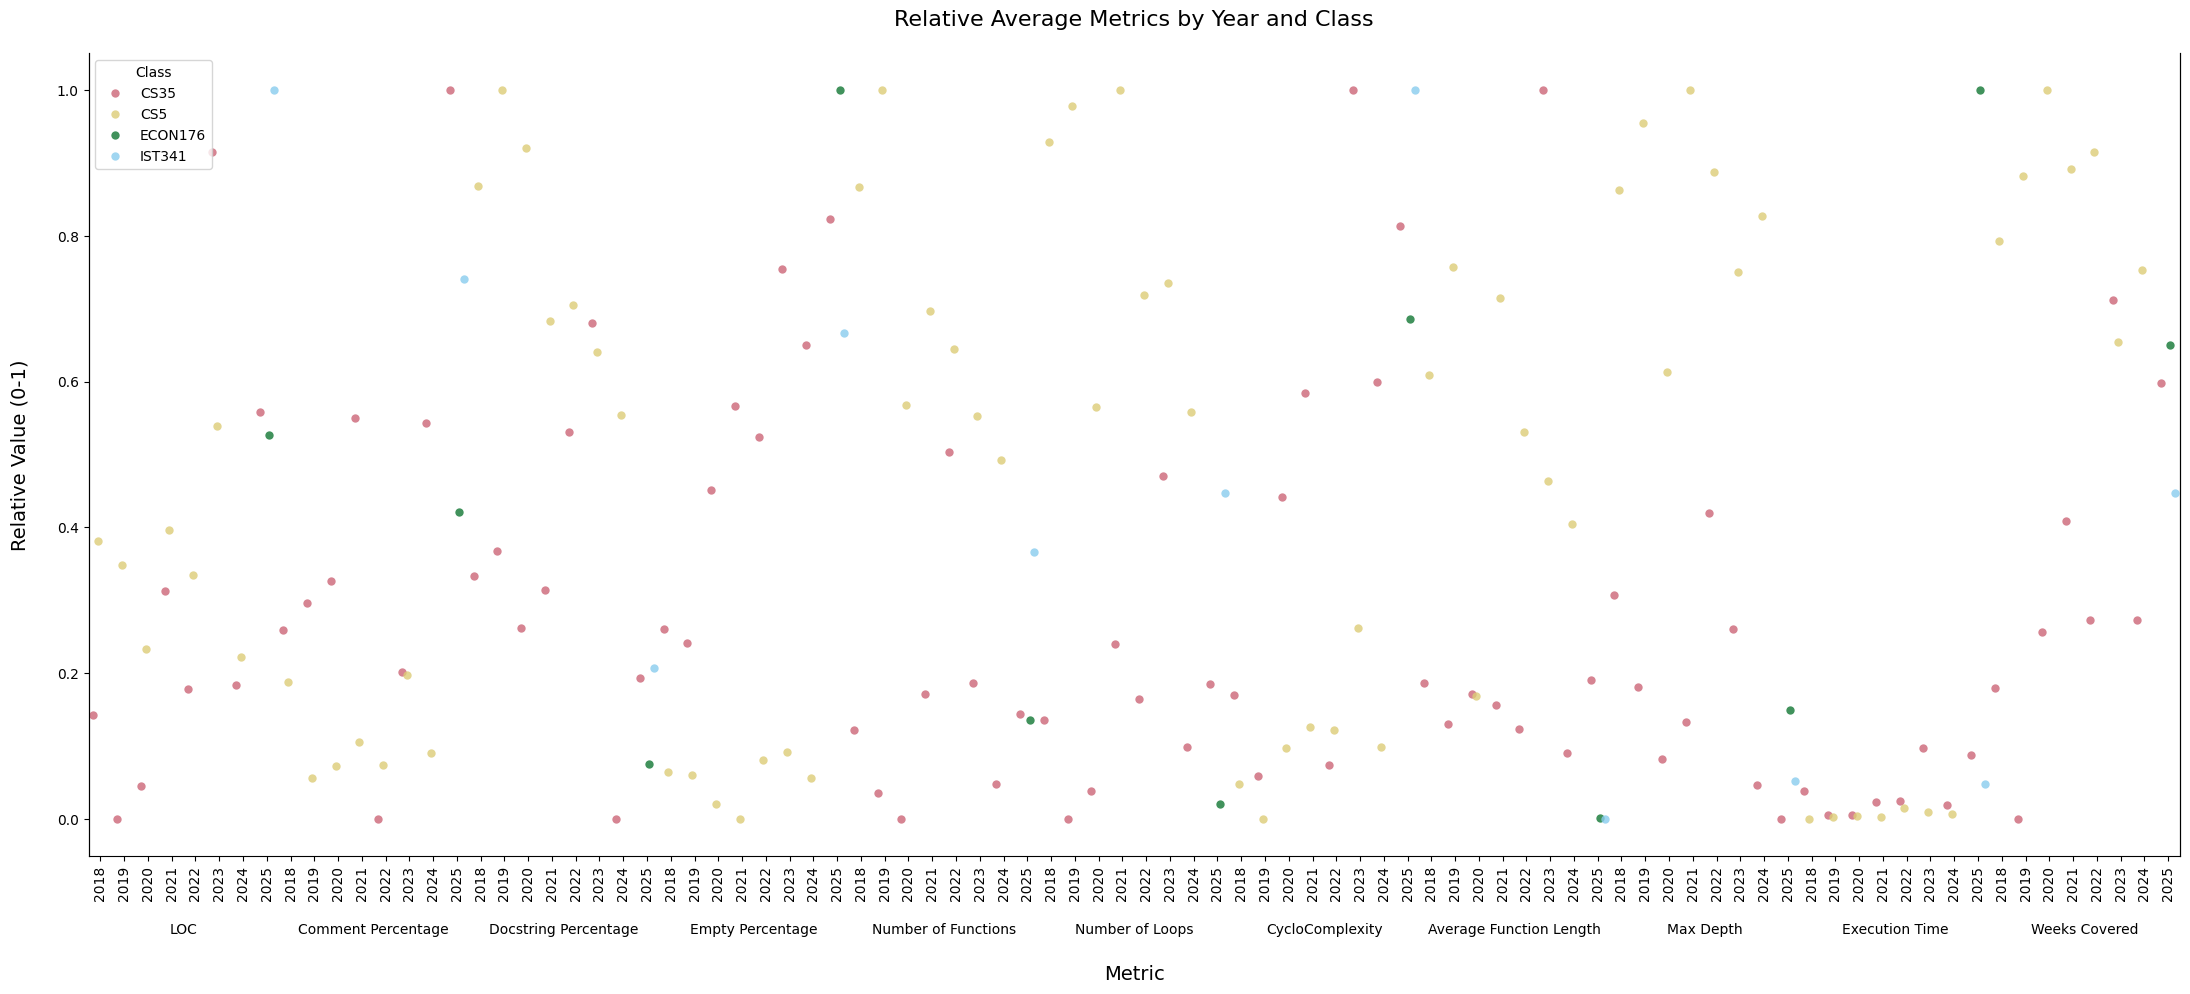

In [89]:
# combined x-axis key: metric-year
metric_order = all_metrics
year_order = list(range(2018, 2026))
melted['Metric-Year'] = melted['Metric'] + '-' + melted['Year'].astype(str)
x_labels = [f"{metric}-{year}" for metric in metric_order for year in year_order]
melted['Metric-Year'] = pd.Categorical(melted['Metric-Year'], categories=x_labels, ordered=True)

# plot
plt.figure(figsize=(22, 10))
ax = sns.stripplot(
    data = melted,
    x = 'Metric-Year',
    y = 'Relative Value',
    hue = 'Class',
    palette = color_palette,
    jitter = True,
    dodge = True,
    alpha = 0.8,
    size = 6,
    order = x_labels
)

# year labels
year_labels = []
for metric in metric_order:
    year_labels.extend([str(year) for year in year_order])
ax.set_xticklabels(year_labels, rotation=90)

# metric labels
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
group_positions = [i * 8 + 3.5 for i in range(len(metric_order))]
ax2.set_xticks(group_positions)
ax2.set_xticklabels(metric_order, fontsize=12)
ax2.tick_params(axis='x', length=0)
ax2.xaxis.set_ticks_position('bottom')
ax2.spines['bottom'].set_position(('outward', 45))
ax2.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['top'].set_visible(False)

# x label
ax.set_xlabel('')
ax2_xmin, ax2_xmax = ax2.get_xlim()
ax2_ymin, ax2_ymax = ax2.get_ylim()
ax2.text(
    (ax2_xmin + ax2_xmax) / 2,
    ax2_ymin - 0.15,
    'Metric',
    ha = 'center',
    va = 'top',
    fontsize = 14,
    transform = ax2.transData
)

plt.title('Relative Average Metrics by Year and Class', fontsize=16, pad=20)
ax.set_ylabel('Relative Value (0-1)', fontsize=14, labelpad=20)

plt.tight_layout()
plt.show()

/var/folders/wq/lbzxr1pd36g5zc91_cmkdntw0000gq/T/ipykernel_38628/660093033.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metric_labels, rotation=90)


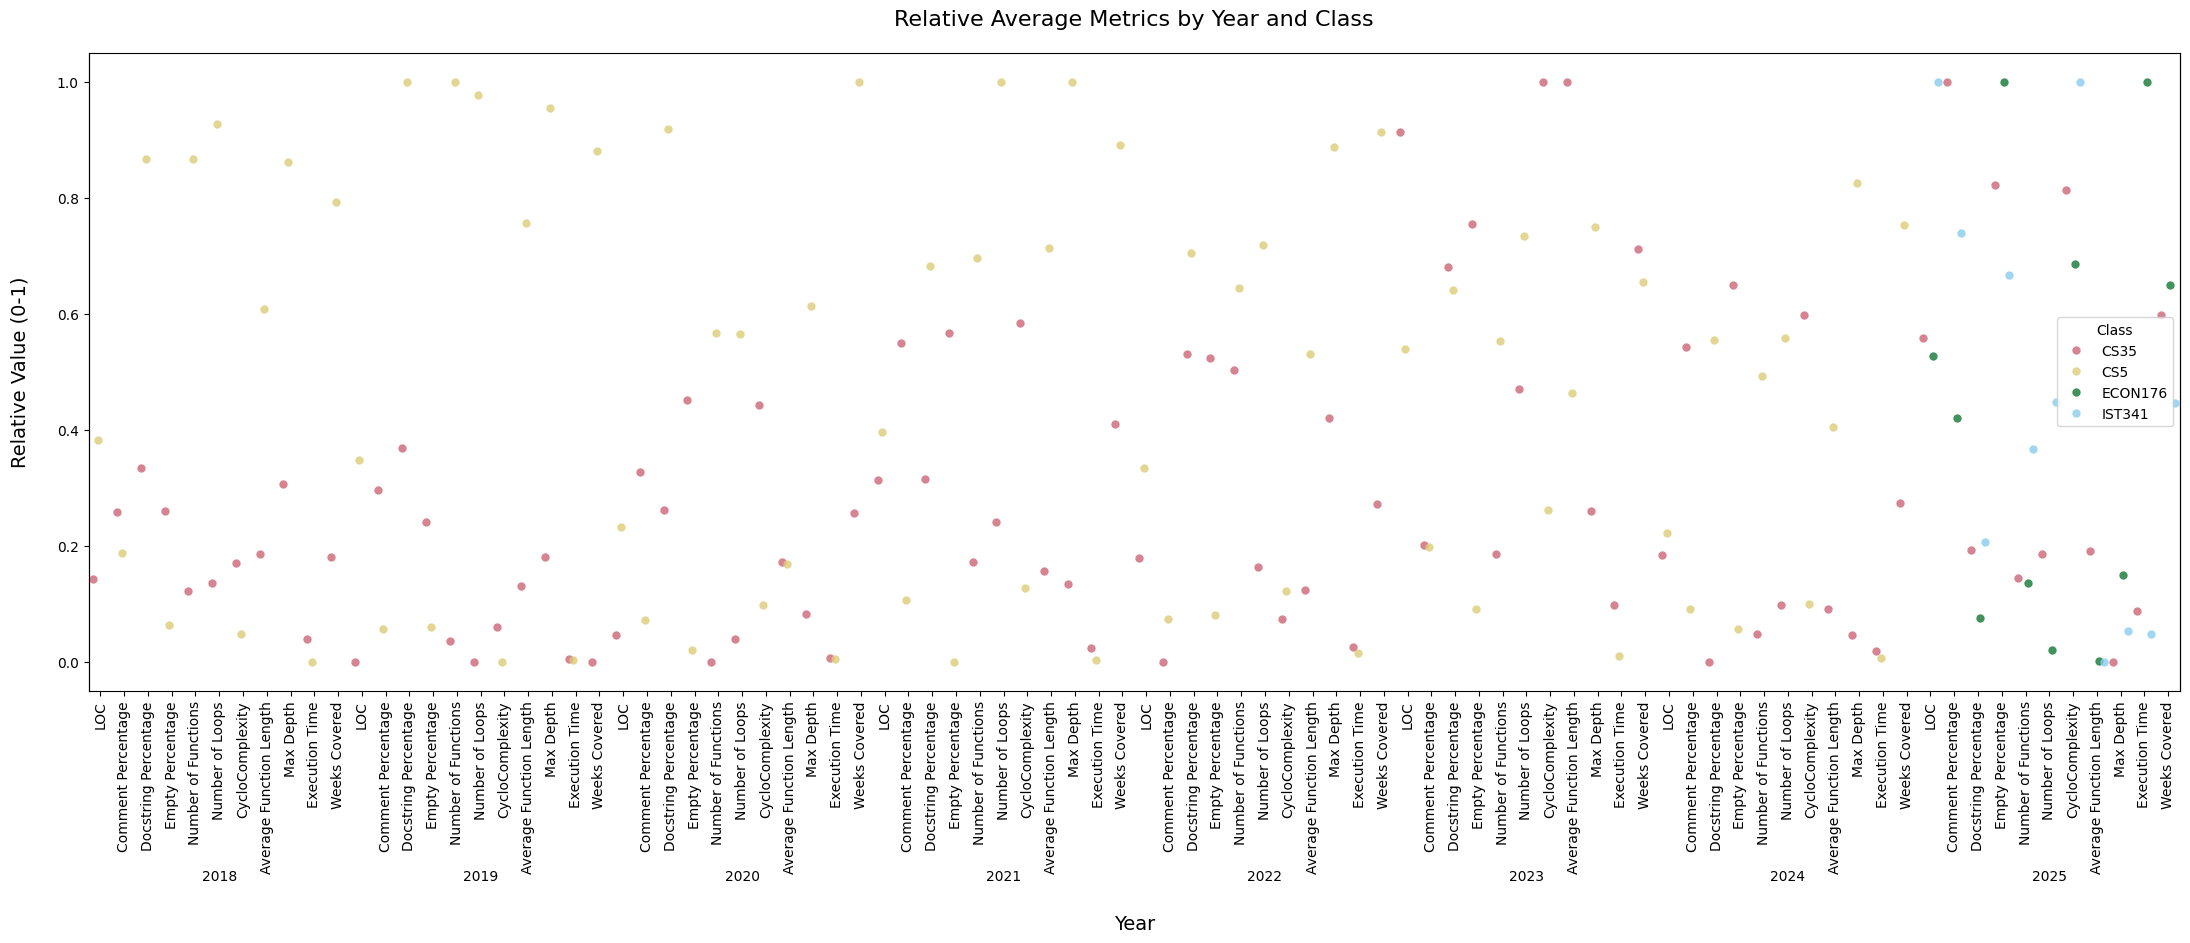

In [90]:
# combined x-axis key: year-metric
year_order = list(range(2018, 2026))
metric_order = all_metrics
melted['Year-Metric'] = melted['Year'].astype(str) + '-' + melted['Metric']
x_labels = [f"{year}-{metric}" for year in year_order for metric in metric_order]
melted['Year-Metric'] = pd.Categorical(melted['Year-Metric'], categories=x_labels, ordered=True)

# plot
plt.figure(figsize=(22, 10))
ax = sns.stripplot(
    data = melted,
    x = 'Year-Metric',
    y = 'Relative Value',
    hue = 'Class',
    palette = color_palette,
    jitter = True,
    dodge = True,
    alpha = 0.8,
    size = 6,
    order = x_labels
)

# metric labels
metric_labels = metric_order * len(year_order)
ax.set_xticklabels(metric_labels, rotation=90)

# year labels
group_size = len(metric_order)
group_positions = [i * group_size + (group_size - 1) / 2 for i in range(len(year_order))]
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(group_positions)
ax2.set_xticklabels(year_order, fontsize=12)
ax2.tick_params(axis='x', length=0)
ax2.xaxis.set_ticks_position('bottom')
ax2.spines['bottom'].set_position(('outward', 125))
ax2.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# x label
ax.set_xlabel('')
ax2.text(
    0.5, -0.35,
    'Year',
    ha = 'center',
    va = 'top',
    fontsize = 14,
    transform = ax2.transAxes
)

plt.title('Relative Average Metrics by Year and Class', fontsize=16, pad=20)
ax.set_ylabel('Relative Value (0-1)', fontsize=14, labelpad=20)

plt.tight_layout()
plt.show()
